<a href="https://colab.research.google.com/github/th900/Ciencia-de-dados-para-o-agronegocio/blob/main/Ci%C3%AAncia_de_dados_para_agronegocio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install catboost

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

warnings.filterwarnings("ignore")

In [18]:
RAW_PATH = "https://raw.githubusercontent.com/th900/Ciencia-de-dados-para-o-agronegocio/refs/heads/main/treino.csv"

df = pd.read_csv(RAW_PATH)
print("=" * 60)
print("1. DATASET CARREGADO")
print(f"   Shape: {df.shape}")
print("=" * 60)

1. DATASET CARREGADO
   Shape: (88858, 10)


In [19]:
df.head(10)

,ID,Estimated_Insects_Count,Crop_Type,Soil_Type,Pesticide_Use_Category,Number_Doses_Week,Number_Weeks_Used,Number_Weeks_Quit,Season,Crop_Damage
0,F00000001,188,1,0,1,0,0.0,0,1,0
1,F00000003,209,1,0,1,0,0.0,0,2,1
2,F00000004,257,1,0,1,0,0.0,0,2,1
3,F00000005,257,1,1,1,0,0.0,0,2,1
4,F00000006,342,1,0,1,0,0.0,0,2,1
5,F00000008,448,0,1,1,0,NaN,0,2,1
6,F00000009,448,0,1,1,0,NaN,0,2,1
7,F00000010,577,1,0,1,0,0.0,0,1,2
8,F00000012,731,0,0,1,0,0.0,0,2,0
9,F00000020,1132,1,0,1,0,0.0,0,1,2


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88858 entries, 0 to 88857
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       88858 non-null  object 
 1   Estimated_Insects_Count  88858 non-null  int64  
 2   Crop_Type                88858 non-null  int64  
 3   Soil_Type                88858 non-null  int64  
 4   Pesticide_Use_Category   88858 non-null  int64  
 5   Number_Doses_Week        88858 non-null  int64  
 6   Number_Weeks_Used        79858 non-null  float64
 7   Number_Weeks_Quit        88858 non-null  int64  
 8   Season                   88858 non-null  int64  
 9   Crop_Damage              88858 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 6.8+ MB


In [21]:
df["Crop_Damage"].value_counts()

,count
Crop_Damage,
0,74238
1,12307
2,2313


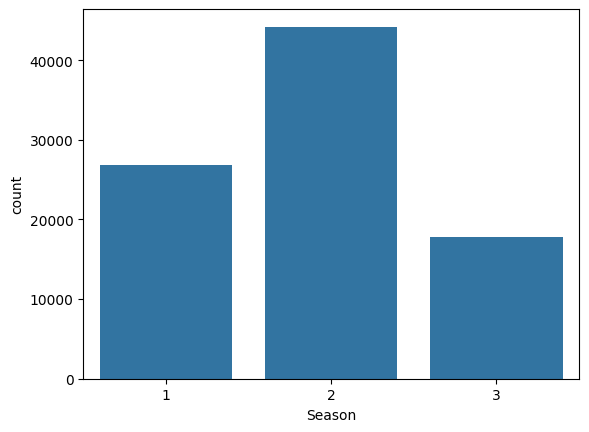

In [22]:
df['Season'].value_counts()
ax = sns.countplot(x=df['Season'])

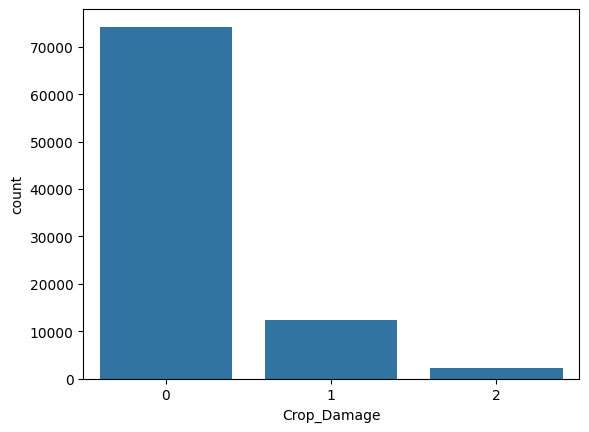

In [23]:
df['Crop_Damage'].value_counts()
ax = sns.countplot(x = df['Crop_Damage'])

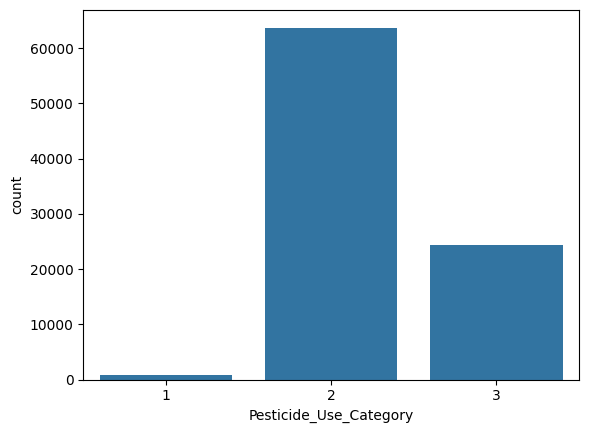

In [24]:
df['Pesticide_Use_Category'].value_counts()
ax = sns.countplot(x = df['Pesticide_Use_Category'])

In [25]:
df.isnull().sum()

,0
ID,0
Estimated_Insects_Count,0
Crop_Type,0
Soil_Type,0
Pesticide_Use_Category,0
Number_Doses_Week,0
Number_Weeks_Used,9000
Number_Weeks_Quit,0
Season,0
Crop_Damage,0


In [26]:
df.duplicated().sum()

np.int64(0)

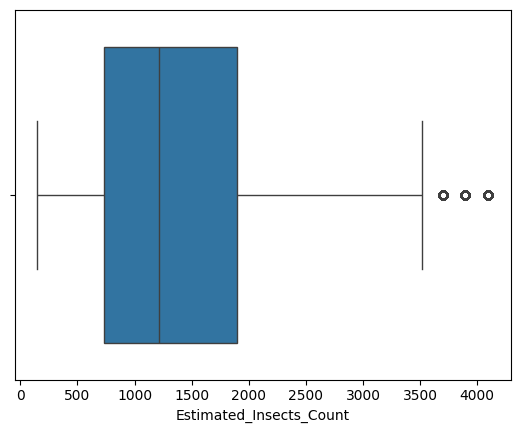

In [27]:
df['Estimated_Insects_Count'].describe()
ax= sns.boxplot( x = df['Estimated_Insects_Count'])

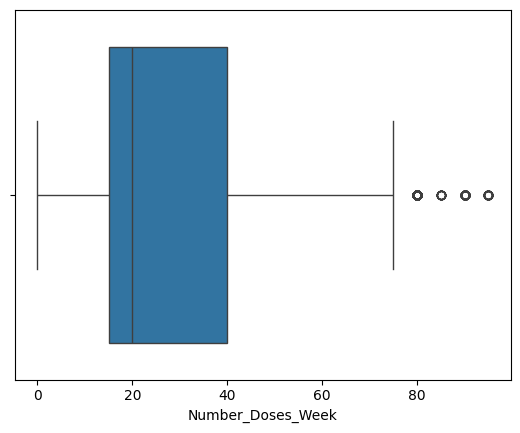

In [28]:
df['Number_Doses_Week'].describe()
ax = sns.boxplot(x = df['Number_Doses_Week'])

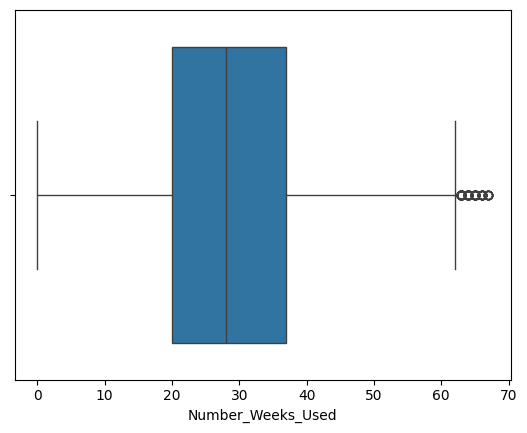

In [29]:
df['Number_Weeks_Used'].describe()
ax = sns.boxplot(x = df['Number_Weeks_Used'])

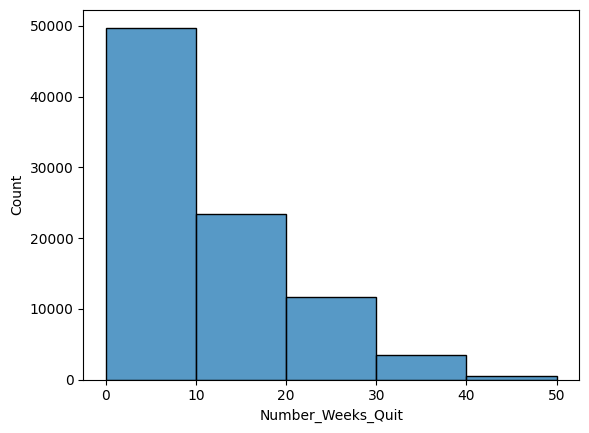

In [30]:
df['Number_Weeks_Quit'].describe()
ax = sns.histplot(x = df['Number_Weeks_Quit'], bins = 5)

In [31]:
df.dropna(inplace=True)

In [32]:
columns = df.columns

In [33]:
for col in ['Crop_Type', 'Soil_Type', 'Pesticide_Use_Category', 'Season']:
  df = pd.get_dummies(df, columns = [col])

In [34]:
df.drop(columns=["ID"], axis = 1, inplace=True)

In [35]:
df.head(4)

,Estimated_Insects_Count,Number_Doses_Week,Number_Weeks_Used,Number_Weeks_Quit,Crop_Damage,Crop_Type_0,Crop_Type_1,Soil_Type_0,Soil_Type_1,Pesticide_Use_Category_1,Pesticide_Use_Category_2,Pesticide_Use_Category_3,Season_1,Season_2,Season_3
0,188,0,0.0,0,0,False,True,True,False,True,False,False,True,False,False
1,209,0,0.0,0,1,False,True,True,False,True,False,False,False,True,False
2,257,0,0.0,0,1,False,True,True,False,True,False,False,False,True,False
3,257,0,0.0,0,1,False,True,False,True,True,False,False,False,True,False


In [36]:
X = df.drop(['Crop_Damage'], axis = 1)
y = df['Crop_Damage']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [49]:


def report_metricas(y_test, y_pred):
    """
    Exibe as principais métricas de classificação para o dano da lavoura.
    """
    # Calculando as métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"--- Relatório de Performance ---")
    print(f"Acurácia:  {acc:.2%}")
    print(f"Precisão:  {prec:.2%}")
    print(f"Recall:    {rec:.2%}")
    print(f"F1-Score:  {f1:.2%}")
    print("-" * 30)
    '''  Matriz de Confusão para ver onde o modelo está errando (ex: trocando dano por praga por dano natural)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusão')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()
    '''

In [53]:
models_name = {
    "Regressão logistica": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
}

for name, model in models_name.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(f"--- {name} ---")
  report_metricas(y_test, y_pred)

--- Regressão logistica ---
--- Relatório de Performance ---
Acurácia:  83.23%
Precisão:  75.93%
Recall:    83.23%
F1-Score:  77.75%
------------------------------
--- Random Forest ---
--- Relatório de Performance ---
Acurácia:  82.62%
Precisão:  78.63%
Recall:    82.62%
F1-Score:  80.04%
------------------------------
--- Decision Tree ---
--- Relatório de Performance ---
Acurácia:  75.10%
Precisão:  76.31%
Recall:    75.10%
F1-Score:  75.68%
------------------------------
--- KNN ---
--- Relatório de Performance ---
Acurácia:  82.63%
Precisão:  77.91%
Recall:    82.63%
F1-Score:  79.63%
------------------------------
--- Gradient Boosting ---
--- Relatório de Performance ---
Acurácia:  84.76%
Precisão:  79.45%
Recall:    84.76%
F1-Score:  80.36%
------------------------------


In [54]:
model = CatBoostClassifier(n_estimators=1000, max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



Learning rate set to 0.097814
0:	learn: 0.9826272	total: 22.8ms	remaining: 22.8s
1:	learn: 0.8956100	total: 44.8ms	remaining: 22.3s
2:	learn: 0.8256431	total: 65.7ms	remaining: 21.8s
3:	learn: 0.7684482	total: 86.9ms	remaining: 21.6s
4:	learn: 0.7220640	total: 109ms	remaining: 21.8s
5:	learn: 0.6827986	total: 130ms	remaining: 21.6s
6:	learn: 0.6504766	total: 152ms	remaining: 21.6s
7:	learn: 0.6226911	total: 174ms	remaining: 21.6s
8:	learn: 0.5994742	total: 195ms	remaining: 21.5s
9:	learn: 0.5785820	total: 217ms	remaining: 21.5s
10:	learn: 0.5612721	total: 239ms	remaining: 21.4s
11:	learn: 0.5459606	total: 259ms	remaining: 21.3s
12:	learn: 0.5325529	total: 280ms	remaining: 21.3s
13:	learn: 0.5207047	total: 301ms	remaining: 21.2s
14:	learn: 0.5102633	total: 322ms	remaining: 21.1s
15:	learn: 0.5012924	total: 343ms	remaining: 21.1s
16:	learn: 0.4940294	total: 363ms	remaining: 21s
17:	learn: 0.4875470	total: 384ms	remaining: 20.9s
18:	learn: 0.4813293	total: 408ms	remaining: 21.1s
19:	learn

In [55]:
report_metricas(y_test, y_pred)

--- Relatório de Performance ---
Acurácia:  84.91%
Precisão:  80.15%
Recall:    84.91%
F1-Score:  80.98%
------------------------------


In [57]:
model = GradientBoostingClassifier(n_estimators = 50, max_depth= 5, subsample=0.8)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [58]:
report_metricas(y_test, y_pred)

--- Relatório de Performance ---
Acurácia:  84.83%
Precisão:  80.45%
Recall:    84.83%
F1-Score:  80.68%
------------------------------
